## VISUALIZING AND UNDERSTANDING THE MNIST DATASET

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

"""
In these lines of code, we are downloading the MNIST dataset from the sklearn library.
We can import the datasets in 3 different formats:
1. fetch_*: Download it from the internet, The by default are made in the pandas Dataframe format. 
2. make_*: Generate the fake dataset randomly.
3. load_*: Load one of small datasets that are pre-downloaded along with the sklearn library itself.

Now, the dataset that we will be downloading is named as 'mnist_784'. We wrote as_frame = False as MNIST dataset is bunch of images, which is not suitable for the dataframe format.
"""

"\nIn these lines of code, we are downloading the MNIST dataset from the sklearn library.\nWe can import the datasets in 3 different formats:\n1. fetch_*: Download it from the internet, The by default are made in the pandas Dataframe format. \n2. make_*: Generate the fake dataset randomly.\n3. load_*: Load one of small datasets that are pre-downloaded along with the sklearn library itself.\n\nNow, the dataset that we will be downloading is named as 'mnist_784'. We wrote as_frame = False as MNIST dataset is bunch of images, which is not suitable for the dataframe format.\n"

In [3]:
x, y = mnist.data, mnist.target
print(x, y)
print(x.shape) # x is a 2D matrix that has 70000 images, and dimension of each image is 28x28, which when flattened out, gives us the 1D array of size 784
print(y.shape) # y is an 1D array that simply contains the TRUE labels of each corresponding image, like the 1st image in MNIST dataset is 5, 2nd is 0, 3rd is 4, etc.

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] ['5' '0' '4' ... '4' '5' '6']
(70000, 784)
(70000,)


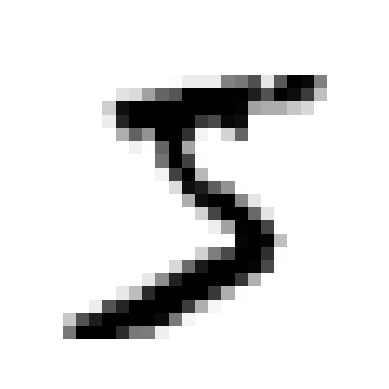

'5'

In [4]:
import matplotlib.pyplot as plt

some_image = x[0] #Loaded a random images from x, say x[0]

def plot_image(some_image):
    image = some_image.reshape(28,28) #Reshaped a 784 array back to its original 2D format.
    plt.imshow(image, cmap="binary") #To create the image in the binary format ie.- black and white
    plt.axis("off")

plot_image(some_image)
plt.show()

y[0]

## Spliting the data into train and test set AND training a classifier

In [5]:
#The scikit dataset for MNIST is already split into training and the testing part where first 60000 images are for training purposes but the remaining ones for testing
x_train, y_train, x_test, y_test = x[:60000], y[:60000], x[60000:], y[60000:]

y_train_5 = (y_train == '5') #Just a true/false mask. Mask can be of different types: we can also write something like: y_train_5 = ['5' if y == '5' else 'no_5' for y in y_train]
y_test_5 = (y_test == '5')

In [6]:
"""
OR if we need to split the training and testing data from sklearn, use:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify=y)

stratify = y just to ensure that we follow stratified sampling during train and test sets creation.
"""

'\nOR if we need to split the training and testing data from sklearn, use:\n\nfrom sklearn.model_selection import train_test_split\nx_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify=y)\n\nstratify = y just to ensure that we follow stratified sampling during train and test sets creation.\n'

In [7]:
from sklearn.linear_model import SGDClassifier
from sklearn.dummy import DummyClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_5) #It is learning: What kind of image patterns lead to True vs False where x_train has raw and unlabelled images, and y_train_5 has true labels wither Truth or Fallacy

sgd_clf.predict([some_image])
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, x_train, y_train_5, cv =5, scoring='accuracy')

array([0.95466667, 0.96975   , 0.9635    , 0.96533333, 0.94841667])

In [8]:
dummy_clf = DummyClassifier()
dummy_clf.fit(x_train, y_train_5)

cross_val_score(dummy_clf, x_train, y_train_5, cv =5, scoring='accuracy')

array([0.90958333, 0.90966667, 0.90966667, 0.90966667, 0.90966667])

Lets us discuss why even a simple classifer like a dummy classifer getting 90% accuracy over such a rigourous dataset.

It is because 90% of the data itself is not 5! So even if the model closes its eyes and blindly say no about the number being 5, it'll be 90% times correct. Hence over a skewed dataset, we don't prefer accuracy as a good matric. We prefer something like confusion matrix, precision, recall, etc.

## Implementing our own cross-validation sets from scratch

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=5, shuffle=True) #This method divides our dataset into 5 equal part using stratified sampling. True label of the data is used for creating these stratas of the data.
for train_index, test_index in skfolds.split(x_train, y_train_5): #We will need to feed not only data, but also train it.
    clone_clf = clone(sgd_clf) #This clones the classifer that will be trained; for each strata. It keeps the hyperparameters exactly the same for each one of the stratas.
    x_train_folds = x_train[train_index]
    y_train_folds = y_train_5[train_index]
    x_test_folds = x_train[test_index]
    y_test_folds = y_train_5[test_index]

    clone_clf.fit(x_train_folds, y_train_folds) #Training occurs only over the training sets of each strata.
    y_pred = clone_clf.predict(x_test_folds) #Testing occurs over the remaining part.
    n_correct = sum(y_pred == y_test_folds) 
    print(n_correct/ len(y_pred)) #Printing the accuracy of the guesses by the machine.    

0.9296666666666666
0.9649166666666666
0.9696666666666667
0.9689166666666666
0.9685833333333334


## Confusion Matrices and Precison, Recall, F1 score

In [10]:
#The whole of idea of confusion matrices it to count the measure of number of instances A (predicted by the machine) vs instances of B (ground truth labels)

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5,  cv=5)

#Just like cross_val_score(), cross_val_predict() performs k-fold cross-validation but instead of returning the evaluation scores it returns the predictions made on each test fold.

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred) 
print(cm)

[[53115  1464]
 [  916  4505]]


In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

p = precision_score(y_train_5, y_train_pred)
r = recall_score(y_train_5, y_train_pred)
f = f1_score(y_train_5, y_train_pred)

print(p)
print(r)
print(f)

0.7547327860613168
0.8310274857037447
0.7910447761194029


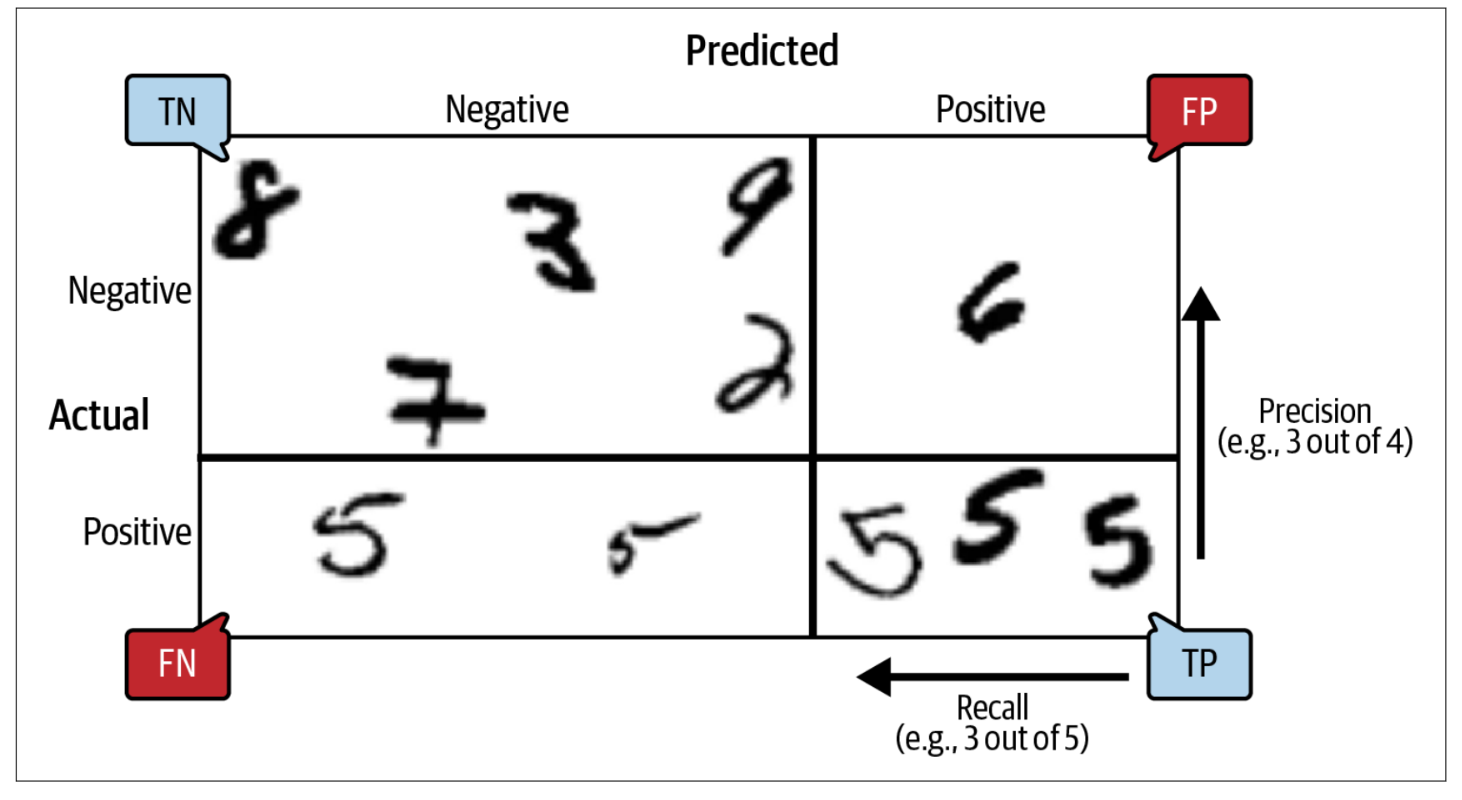

In [13]:
from IPython.display import Image
img_path = "/home/piyush/Pictures/Screenshot from 2026-04-11 15-12-11.png"
Image(filename=img_path, width=1000)

#X-axis contains the predictions made by the machine, while Y-axis has true ground labels. Our job is to classify 5.

In [14]:
y_scores = sgd_clf.decision_function([some_image])
print(y_scores)

threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

[2164.22030239]


array([ True])

In [15]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

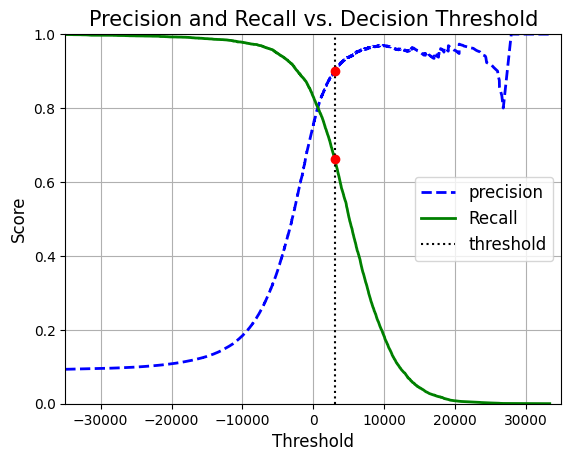

In [33]:
#To decide on the best hyperparameter value for the threshold, we should use precision_recall_curve() function.

from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, x_train, y_train_5, cv =5, method = 'decision_function')
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
idx = (thresholds >= threshold).argmax()

plt.plot(thresholds, precisions[:-1], 'b--', label = 'precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='threshold')
plt.plot(thresholds[idx], precisions[idx], 'ro')
plt.plot(thresholds[idx], recalls[idx], 'ro')
plt.grid(True)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision and Recall vs. Decision Threshold', fontsize = 15)
plt.legend(loc = 'center right', fontsize = 12)
plt.axis([-35000, 35000, 0, 1])
plt.show()

#### Creating a classifer with 90% precision

In [34]:
idx_for_90_precison = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precison]
threshold_for_90_precision

np.float64(3045.9258227053638)

In [36]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

print(precision_score(y_train_5, y_train_pred_90))
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
print(recall_at_90_precision)

0.9002016129032258
0.6589190186312488
